# WBF Visual Check — RT-DETR-X (Exp D) + RT-DETR-L (Exp C)

Quick sanity check notebook: do the two RT-DETR checkpoints agree on where the RFI actually is?

For a handful of val images we plot, side by side:
1. **Exp D (X)** raw detections
2. **Exp C (L)** raw detections
3. **WBF fusion (avg)** of the two
4. **Ground truth** annotations

If X and L hit roughly the same boxes on the same images, WBF has a chance. If they disagree wildly, fusion will just average noise.

## Imports & paths

Only the minimum needed for inference + plotting — no COCO eval machinery here.

In [6]:
import json
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

from ultralytics import YOLO
from ensemble_boxes import weighted_boxes_fusion

CLEARSAR = Path('.')
ROOT     = CLEARSAR / 'data'
ANN_FILE = ROOT / 'annotations' / 'instances_train.json'
VAL_TXT  = CLEARSAR / 'val_split.txt'

EXP_D_BEST = Path('runs/clearsar/exp_d_rtdetr_x/weights/best.pt')
EXP_C_BEST = Path('runs/clearsar/exp_c_rtdetr_l/weights/best.pt')
assert EXP_D_BEST.exists(), f'Missing: {EXP_D_BEST}'
assert EXP_C_BEST.exists(), f'Missing: {EXP_C_BEST}'

WBF_IOU_THR      = 0.25
WBF_WEIGHTS      = [1.0, 1.0]
WBF_SKIP_BOX_THR = 0.0

INF_CONF = 0.02
INF_IOU  = 0.5

print('Exp D (X):', EXP_D_BEST)
print('Exp C (L):', EXP_C_BEST)

Exp D (X): runs\clearsar\exp_d_rtdetr_x\weights\best.pt
Exp C (L): runs\clearsar\exp_c_rtdetr_l\weights\best.pt


## Helpers — per-model inference and WBF fusion

`predict_model` returns raw xyxy boxes + scores. Pass PIL directly so Ultralytics doesn't silently BGR-swap.

`fuse_two` normalizes both sets of boxes to 0–1, runs WBF, then scales back to pixel space.

In [7]:
def predict_model(model, pil_img):
    r = model.predict(source=pil_img, imgsz=640, conf=INF_CONF,
                      iou=INF_IOU, device=0, verbose=False)[0]
    if r.boxes is None or len(r.boxes) == 0:
        return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.float32)
    return (r.boxes.xyxy.cpu().numpy().astype(np.float32),
            r.boxes.conf.cpu().numpy().astype(np.float32))


def fuse_two(boxes_a, scores_a, boxes_b, scores_b, W, H, conf_type='avg'):
    def norm(b):
        if len(b) == 0:
            return np.zeros((0, 4), dtype=np.float32)
        nb = b.copy()
        nb[:, [0, 2]] = np.clip(nb[:, [0, 2]] / W, 0.0, 1.0)
        nb[:, [1, 3]] = np.clip(nb[:, [1, 3]] / H, 0.0, 1.0)
        return nb

    boxes_list  = [norm(boxes_a).tolist(), norm(boxes_b).tolist()]
    scores_list = [scores_a.tolist(),     scores_b.tolist()]
    labels_list = [[0] * len(scores_a),   [0] * len(scores_b)]

    if sum(len(s) for s in scores_list) == 0:
        return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.float32)

    fb, fs, _ = weighted_boxes_fusion(
        boxes_list, scores_list, labels_list,
        weights      = WBF_WEIGHTS,
        iou_thr      = WBF_IOU_THR,
        skip_box_thr = WBF_SKIP_BOX_THR,
        conf_type    = conf_type,
    )
    fb = np.asarray(fb, dtype=np.float32)
    fs = np.asarray(fs, dtype=np.float32)
    if len(fb):
        fb[:, [0, 2]] *= W
        fb[:, [1, 3]] *= H
    return fb, fs

## Load models and ground truth

Both checkpoints into memory, plus a `{image_id: [bbox, ...]}` lookup from the COCO annotations file.

In [8]:
model_x = YOLO(str(EXP_D_BEST))
model_l = YOLO(str(EXP_C_BEST))

val_paths = [Path(p.strip()) for p in VAL_TXT.read_text().splitlines() if p.strip()]

with open(ANN_FILE) as f:
    _ann_raw = json.load(f)
_stem_to_id = {Path(im['file_name']).stem: im['id'] for im in _ann_raw['images']}
_gt_by_id = defaultdict(list)
for a in _ann_raw['annotations']:
    _gt_by_id[a['image_id']].append(a['bbox'])

print(f'Val images: {len(val_paths)}  |  GT-annotated images: {len(_gt_by_id)}')

Val images: 315  |  GT-annotated images: 3120


## Side-by-side comparison

Four columns per row — X / L / WBF / GT — for a handful of val images. Change `SAMPLES` to look at different ones.

Lime = model detections (only drawn if `score ≥ 0.1`), red = ground truth.

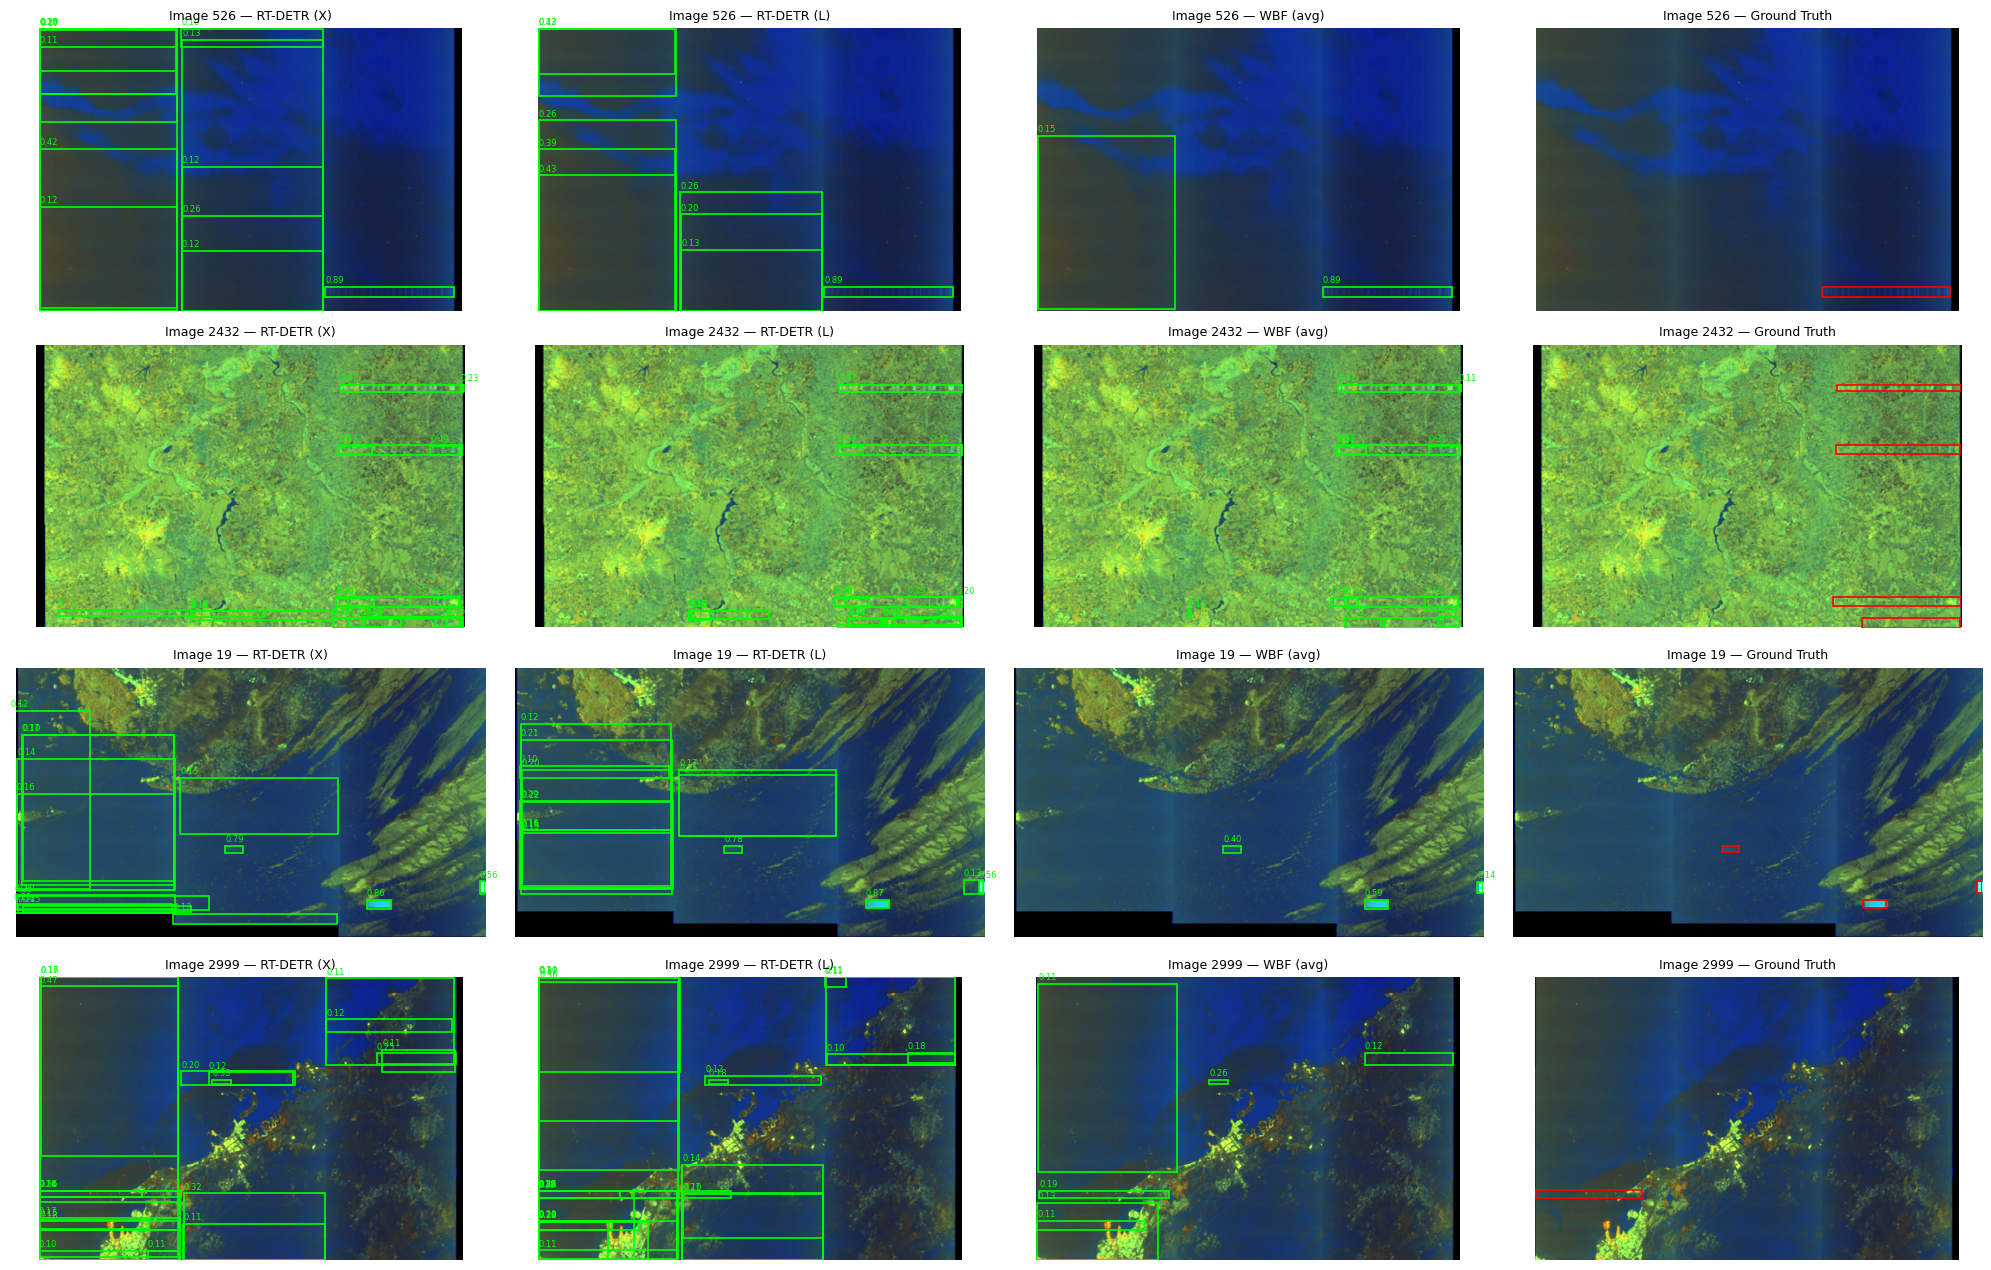

In [9]:
SAMPLES = [val_paths[i] for i in [0, 5, 12, 25] if i < len(val_paths)]

fig, axes = plt.subplots(len(SAMPLES), 4, figsize=(20, 3.2 * len(SAMPLES)))
if len(SAMPLES) == 1:
    axes = axes[None, :]

for row, sample in enumerate(SAMPLES):
    img = Image.open(sample).convert('RGB')
    W, H = img.size
    bx, sx = predict_model(model_x, img)
    bl, sl = predict_model(model_l, img)
    fb_avg, fs_avg = fuse_two(bx, sx, bl, sl, W, H, conf_type='avg')
    gt_boxes = _gt_by_id.get(_stem_to_id.get(sample.stem), [])

    panels = [
        (f'Image {sample.stem} — RT-DETR (X)',     bx,       sx,      'xyxy', 'lime'),
        (f'Image {sample.stem} — RT-DETR (L)',     bl,       sl,      'xyxy', 'lime'),
        (f'Image {sample.stem} — WBF (avg)', fb_avg,   fs_avg,  'xyxy', 'lime'),
        (f'Image {sample.stem} — Ground Truth',      gt_boxes, None,    'xywh', 'red'),
    ]
    for ax, (title, boxes, scores, fmt, color) in zip(axes[row], panels):
        ax.imshow(img); ax.set_title(title, fontsize=9); ax.axis('off')
        for i, b in enumerate(boxes):
            if fmt == 'xyxy':
                x1, y1, x2, y2 = b
                s = scores[i]
                if s < 0.1: continue
                ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                                linewidth=1.2, edgecolor=color, facecolor='none'))
                ax.text(x1, y1 - 2, f'{s:.2f}', color=color, fontsize=6, va='bottom')
            else:
                x, y, w, h = b
                ax.add_patch(mpatches.Rectangle((x, y), w, h,
                                                linewidth=1.2, edgecolor=color, facecolor='none'))

plt.tight_layout(); plt.show()

## Same check with NMS instead of WBF

WBF averages overlapping boxes. NMS just keeps the highest-scoring box and drops overlapping lower-scoring ones. Useful baseline to see what fusion actually buys us.

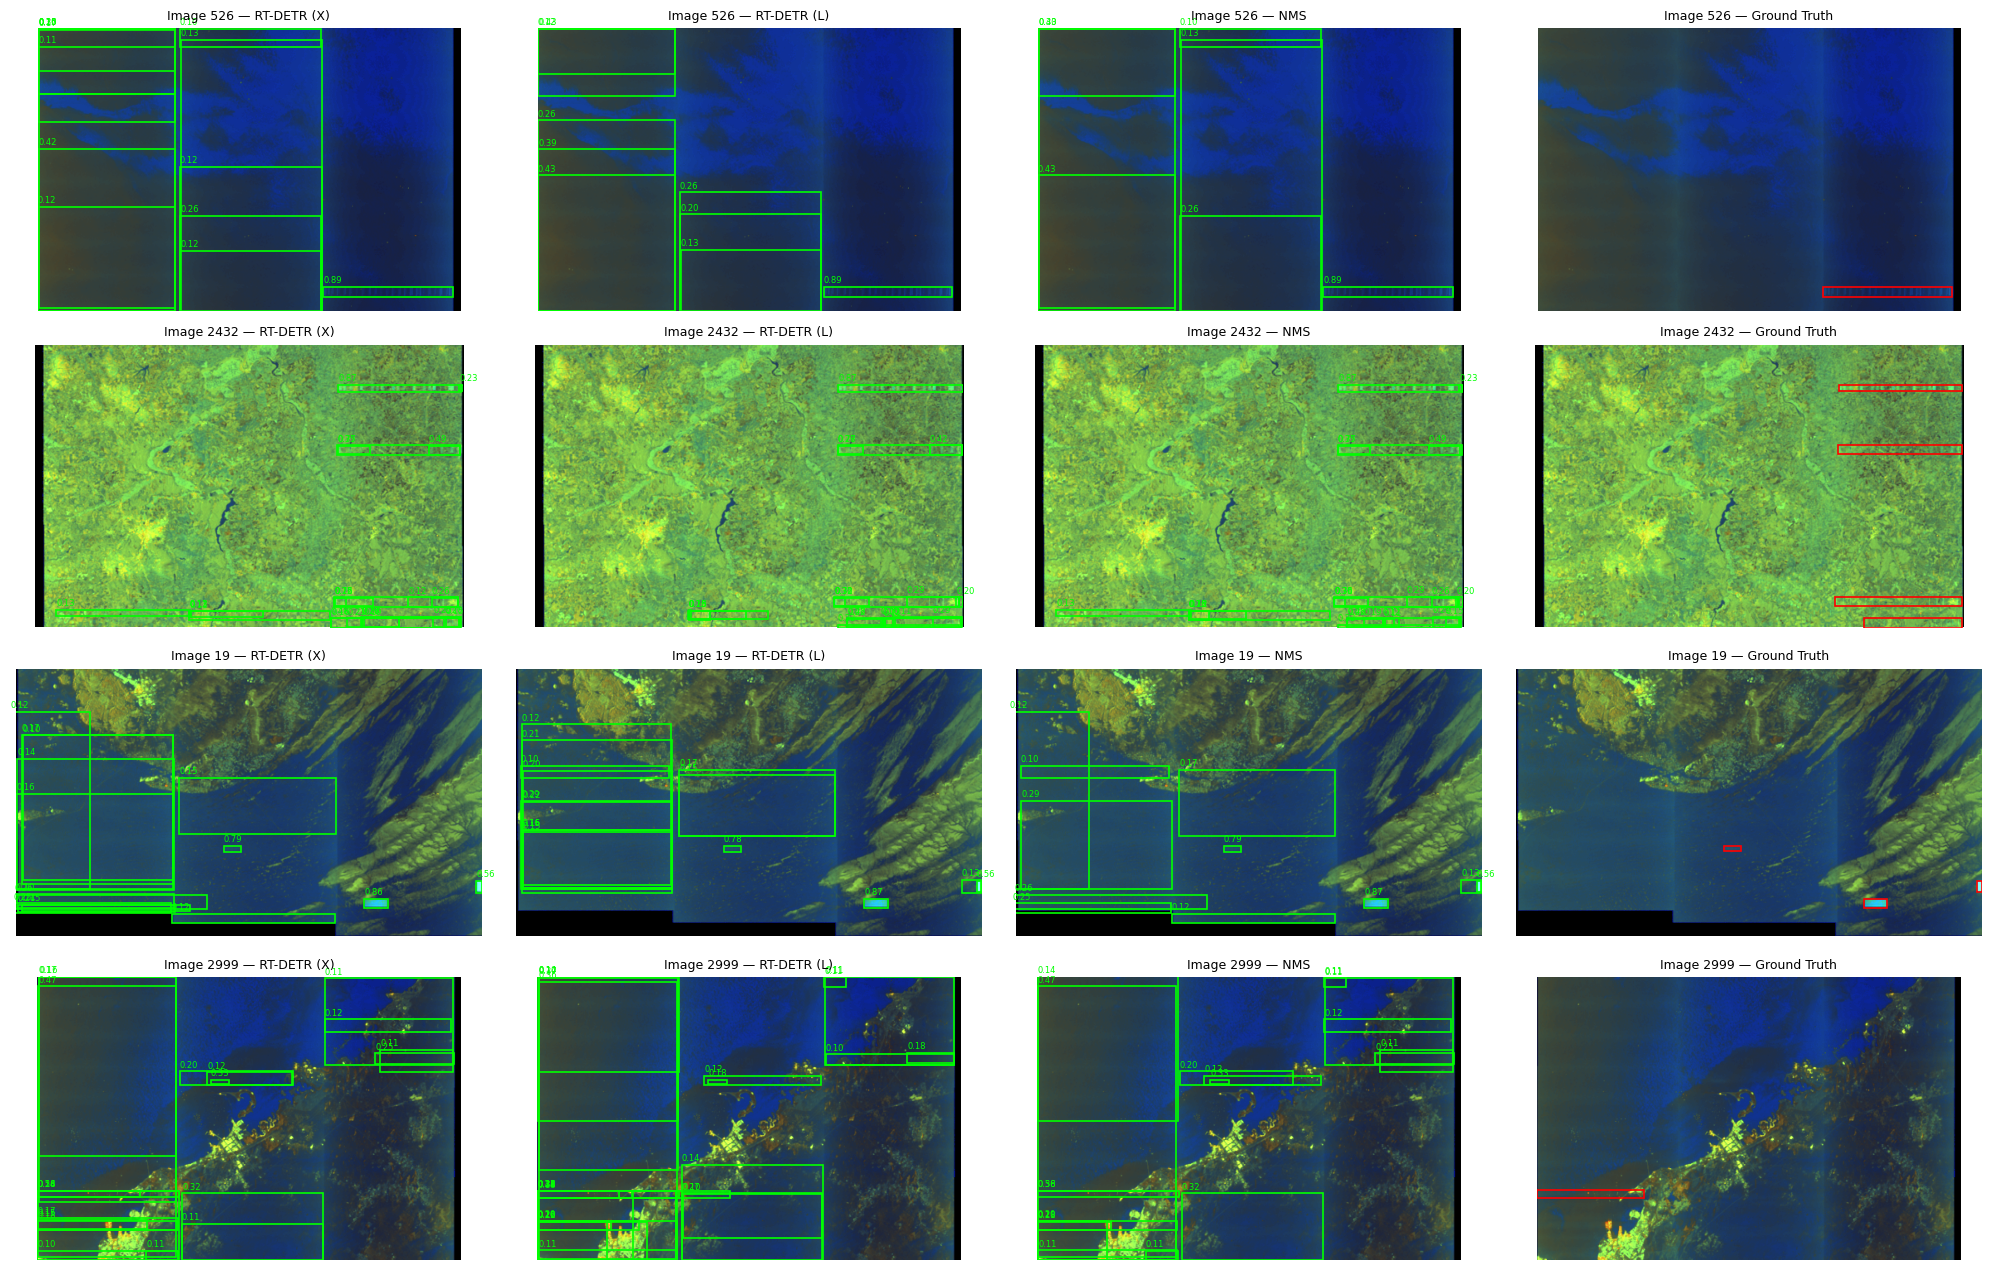

In [10]:
NMS_IOU_THR = 0.5

def nms_two(boxes_a, scores_a, boxes_b, scores_b, iou_thr=NMS_IOU_THR):
    boxes  = np.concatenate([boxes_a,  boxes_b ], axis=0) if len(boxes_a) or len(boxes_b) else np.zeros((0, 4), np.float32)
    scores = np.concatenate([scores_a, scores_b], axis=0) if len(scores_a) or len(scores_b) else np.zeros((0,), np.float32)
    if len(boxes) == 0:
        return boxes, scores

    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]
    keep = []
    while order.size > 0:
        i = order[0]; keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        inter = np.maximum(0, xx2 - xx1) * np.maximum(0, yy2 - yy1)
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-9)
        order = order[1:][iou <= iou_thr]
    keep = np.asarray(keep, dtype=int)
    return boxes[keep], scores[keep]


fig, axes = plt.subplots(len(SAMPLES), 4, figsize=(20, 3.2 * len(SAMPLES)))
if len(SAMPLES) == 1:
    axes = axes[None, :]

for row, sample in enumerate(SAMPLES):
    img = Image.open(sample).convert('RGB')
    W, H = img.size
    bx, sx = predict_model(model_x, img)
    bl, sl = predict_model(model_l, img)
    fb_nms, fs_nms = nms_two(bx, sx, bl, sl)
    gt_boxes = _gt_by_id.get(_stem_to_id.get(sample.stem), [])

    panels = [
        (f'Image {sample.stem} — RT-DETR (X)',     bx,       sx,      'xyxy', 'lime'),
        (f'Image {sample.stem} — RT-DETR (L)',     bl,       sl,      'xyxy', 'lime'),
        (f'Image {sample.stem} — NMS',       fb_nms,   fs_nms,  'xyxy', 'lime'),
        (f'Image {sample.stem} — Ground Truth',      gt_boxes, None,    'xywh', 'red'),
    ]
    for ax, (title, boxes, scores, fmt, color) in zip(axes[row], panels):
        ax.imshow(img); ax.set_title(title, fontsize=9); ax.axis('off')
        for i, b in enumerate(boxes):
            if fmt == 'xyxy':
                x1, y1, x2, y2 = b
                s = scores[i]
                if s < 0.1: continue
                ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                                linewidth=1.2, edgecolor=color, facecolor='none'))
                ax.text(x1, y1 - 2, f'{s:.2f}', color=color, fontsize=6, va='bottom')
            else:
                x, y, w, h = b
                ax.add_patch(mpatches.Rectangle((x, y), w, h,
                                                linewidth=1.2, edgecolor=color, facecolor='none'))

plt.tight_layout(); plt.show()